In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Rutas
base_path = r"C:\Users\braya\Documents\TFM_UCM_Enagas\tfm_enagas"

ruta_sensores_clean = os.path.join(base_path, "data", "processed", "df_sensores_ERM_400_2023_2024_limpio.csv")
#ruta_sensores_clean = os.path.join(base_path, "data", "processed", "df_sensores_ERM_6500_2022_2023_limpio.csv")

ruta_sap_clean = os.path.join(base_path, "data", "processed", "df_sap_erm_400_limpio.csv")
#ruta_sap_clean = os.path.join(base_path, "data", "processed", "df_sap_erm_6500_limpio.csv")

# 2. Cargar Sensores (Forzamos que 'datetime' vuelva a ser el índice y sea tipo fecha)
df = pd.read_csv(ruta_sensores_clean, parse_dates=['datetime'])
df.set_index('datetime', inplace=True)

# 3. Cargar SAP
df_sap = pd.read_csv(ruta_sap_clean, parse_dates=['datetime_fallo'])

print("Datos cargados y listos para el Análisis Exploratorio.")

Datos cargados y listos para el Análisis Exploratorio.


In [3]:
df.shape, df_sap.shape

((105109, 12), (10, 19))

In [5]:
df.head(3)

,presion_in_A,presion_in_B,temperatura_in_A,temperatura_in_B,caudal_bruto_A,caudal_bruto_B,caudal_nominal_A,caudal_nominal_B,caudal_min_diario_A,caudal_min_diario_B,caudal_max_diario_A,caudal_max_diario_B
datetime,,,,,,,,,,,,
2023-01-01 00:00:00,16.784145,16.792011,11.613059,4.581303,0.0,49.199109,0.0,841.179544,0,0,64135.745844,13746.320905
2023-01-01 00:05:00,16.760601,16.767427,11.588407,13.210862,0.0,41.060760,0.0,677.303323,0,0,64135.745844,13746.320905
2023-01-01 00:10:00,16.730278,16.738071,11.562312,16.203283,0.0,42.931357,0.0,698.337504,0,0,64135.745844,13746.320905


In [6]:
df_sap.head(3)

,Aviso,DESCRIPCIÓN AVISO,UT,Denominación,Equipo,Denominación.1,GR-SUBGR,TAMAÑO ERM,Aviso externo,Orden,Inicio deseado,Fin deseado,Inicio avería,Ini.avería (h),Fin de avería,Fin de avería.1,Ce.emplazam.,COMENTARIOS AVISOS,datetime_fallo
0,10225917,ERM_400 Loeches Regulación,ERM_400,Regulación,5.000103e+09,17001 Regulador de gas VCP1A,17001.0,"G-400 6""",20220206-005-IN,400001850178,2022-02-06,2022-02-11,NaN,00:00:00,NaN,00:00:00,7416,10.40 Monitor de la línea principal.\nEntrada ...,2022-02-06
1,10225923,ERM_400 Loeches Regulación,ERM_400,Regulación,5.000103e+09,17001 Regulador de gas VCP1A,17001.0,"G-400 6""",20220206-008-IN,400001818387,2022-02-06,2022-02-11,NaN,00:00:00,NaN,00:00:00,7416,10.40 Se recibe aviso de CPC 10225917 de la ER...,2022-02-06
2,10243490,27/01/23 Correcion Fugas ERM ERM_400,ERM_400,Mecánico,NaN,NaN,NaN,"G-400 6""",NaN,400002001754,2023-01-30,2024-01-30,NaN,00:00:00,NaN,00:00:00,7416,aprobechando que vamos a despresurizar las lin...,2023-01-30


### Analisis Exploratorio y Descriptivo

Histogramas

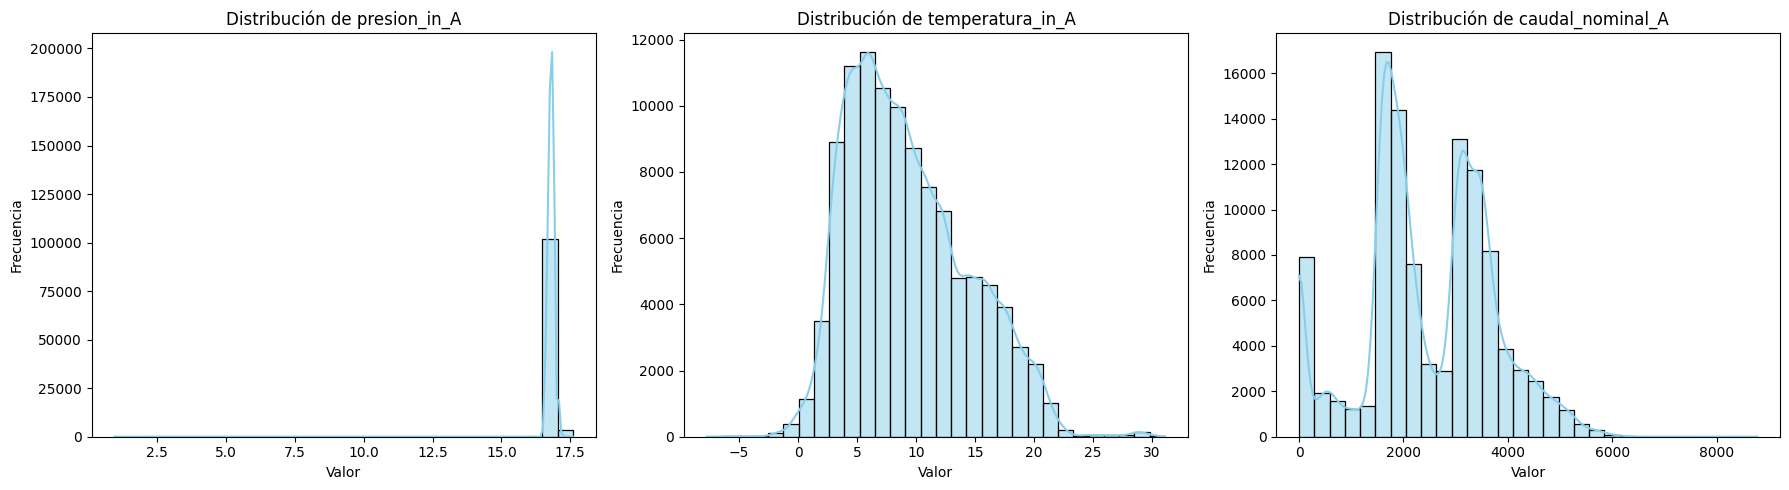

In [7]:
cols_interes = ['presion_in_A', 'temperatura_in_A', 'caudal_nominal_A']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cols_interes):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue', bins=30)
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Boxplots: El detector de Outliers visual

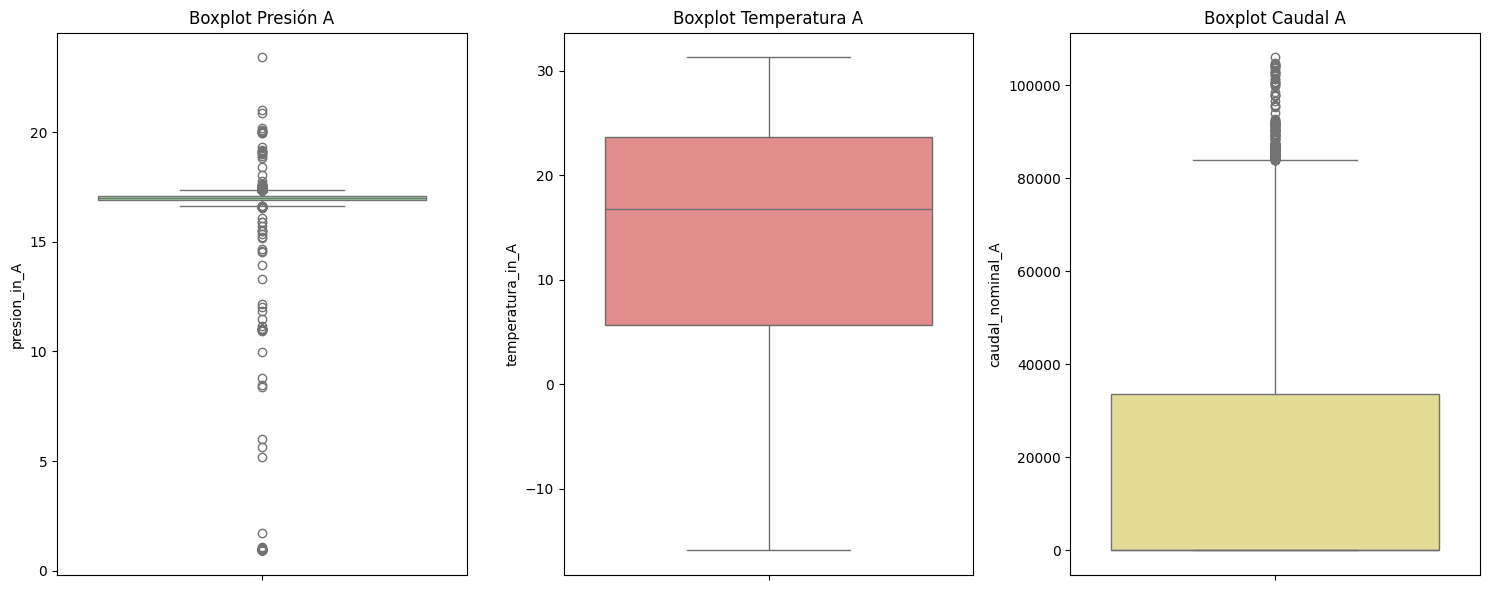

In [6]:
plt.figure(figsize=(15, 6))

# Normalizamos un poco para que se vean bien en el mismo gráfico o los hacemos por separado
plt.subplot(1, 3, 1)
sns.boxplot(y=df['presion_in_A'], color='lightgreen')
plt.title('Boxplot Presión A')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['temperatura_in_A'], color='lightcoral')
plt.title('Boxplot Temperatura A')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['caudal_nominal_A'], color='khaki')
plt.title('Boxplot Caudal A')

plt.tight_layout()
plt.show()

Análisis de Outliers (Cuantificación)No basta con ver los gráficos; en una tesis hay que medir. Vamos a usar el método del Rango Intercuartílico ($IQR$) para decir cuántos valores "extraños" hay 

In [8]:
# Metodo de IQR
def calcular_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = data[(data < limite_inferior) | (data > limite_superior)]
    return outliers

for col in cols_interes:
    puntos_fuera = calcular_outliers_iqr(df[col])
    porcentaje = (len(puntos_fuera) / len(df)) * 100
    print(f"Variable {col}: {len(puntos_fuera)} outliers detectados ({porcentaje:.2f}%)")

Variable presion_in_A: 909 outliers detectados (0.86%)
Variable temperatura_in_A: 361 outliers detectados (0.34%)
Variable caudal_nominal_A: 60 outliers detectados (0.06%)


Análisis de Densidad por Turnos (Mañana, Tarde, Noche).

C:\Users\braya\AppData\Local\Temp\ipykernel_28904\860647152.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='turno', y='presion_in_A', data=df, palette='Pastel1')


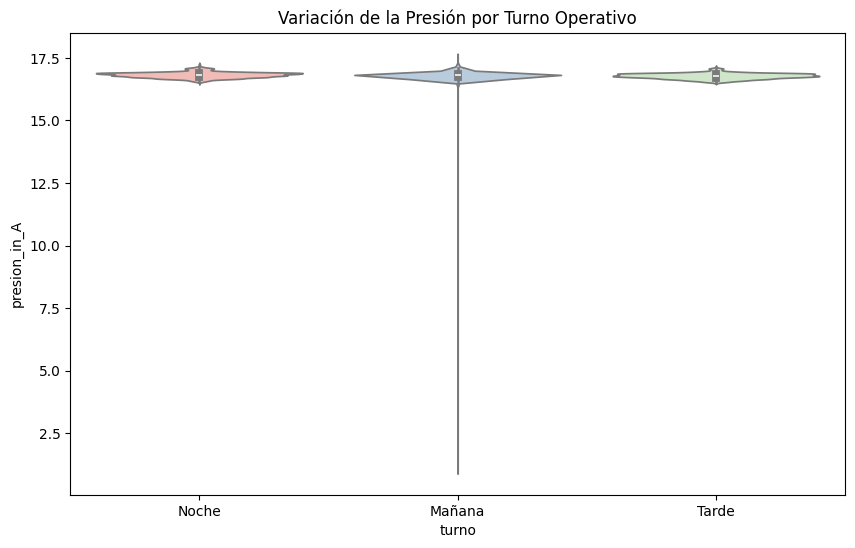

In [9]:
# Definir turnos
def asignar_turno(hora):
    if 6 <= hora < 14: return 'Mañana'
    elif 14 <= hora < 22: return 'Tarde'
    else: return 'Noche'

df['turno'] = df.index.hour.map(asignar_turno)

plt.figure(figsize=(10, 6))
sns.violinplot(x='turno', y='presion_in_A', data=df, palette='Pastel1')
plt.title('Variación de la Presión por Turno Operativo')
plt.show()

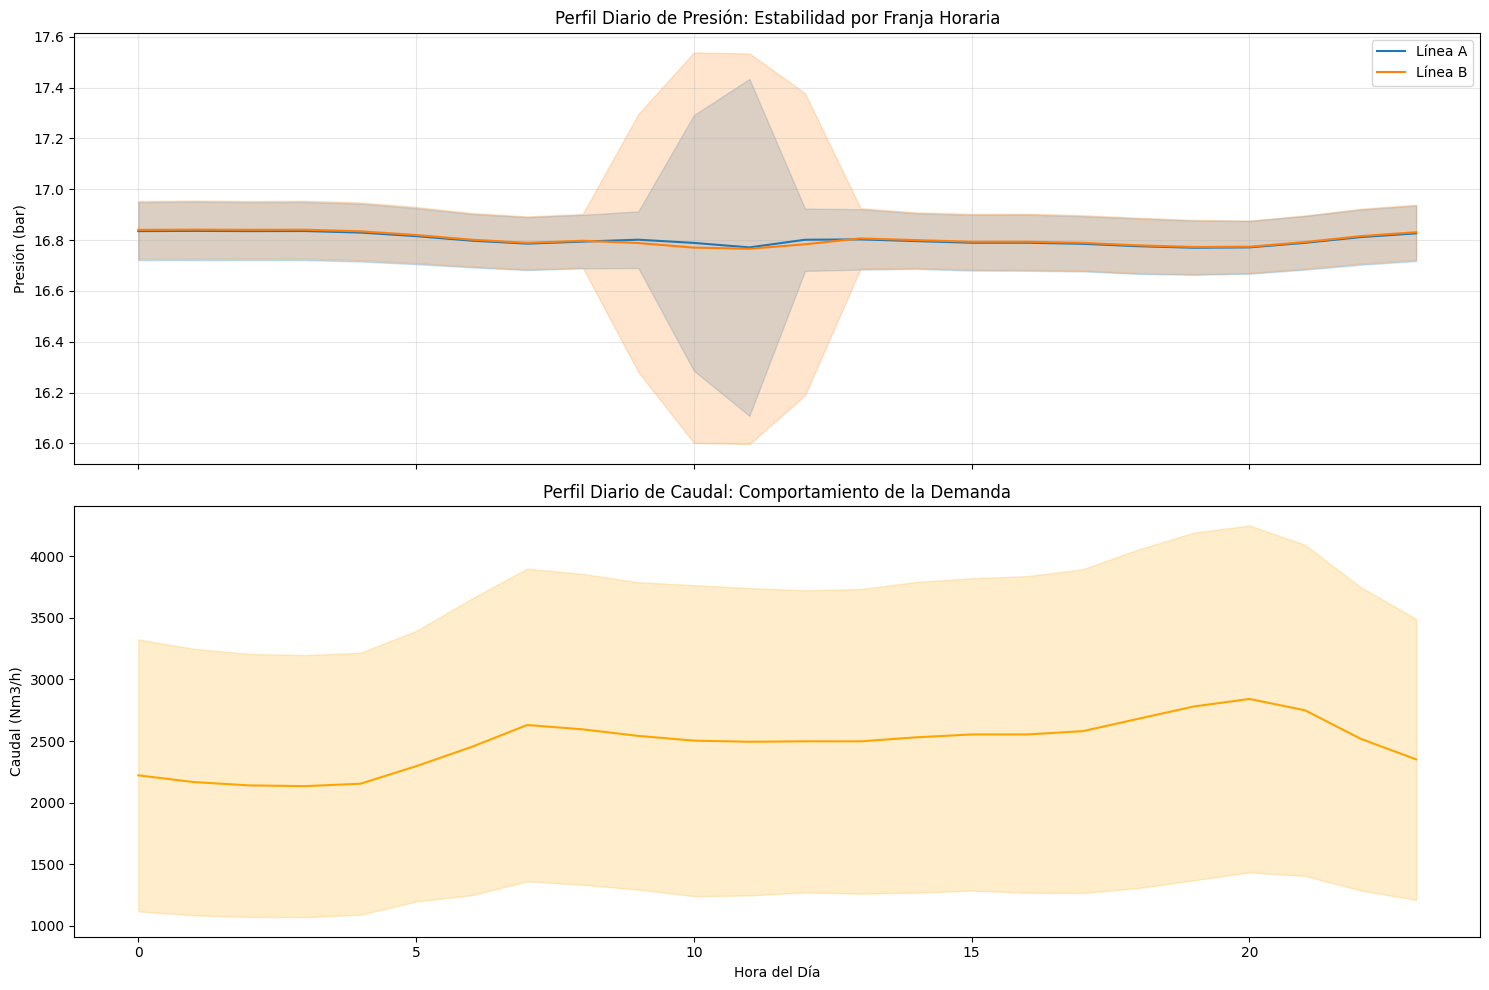

In [4]:
# FIX: Asegurar índice temporal antes de extraer la hora
if not isinstance(df.index, pd.DatetimeIndex):
    df.index = pd.to_datetime(df.index)

df['hora'] = df.index.hour

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Perfil de Presión (Usando errorbar='sd' para versiones nuevas de Seaborn)
sns.lineplot(data=df, x='hora', y='presion_in_A', ax=ax1, errorbar='sd', label='Línea A')
sns.lineplot(data=df, x='hora', y='presion_in_B', ax=ax1, errorbar='sd', label='Línea B')
#sns.lineplot(data=df, x='hora', y='presion_in_C', ax=ax1, errorbar='sd', label='Línea C')
ax1.set_title('Perfil Diario de Presión: Estabilidad por Franja Horaria')
ax1.set_ylabel('Presión (bar)')
ax1.grid(True, alpha=0.3)

# Perfil de Caudal
sns.lineplot(data=df, x='hora', y='caudal_nominal_A', ax=ax2, errorbar='sd', color='orange')
ax2.set_title('Perfil Diario de Caudal: Comportamiento de la Demanda')
ax2.set_ylabel('Caudal (Nm3/h)')

plt.xlabel('Hora del Día')
plt.tight_layout()
plt.show()

In [10]:
# Cálculo correcto: Diferencia temporal en la misma línea (Línea C)
# Usamos .abs() porque el manual habla de "fluctuaciones" (subidas o bajadas bruscas)
df['delta_presion_temp'] = df['presion_in_A'].diff().abs()

3. Relación Caudal-Presión

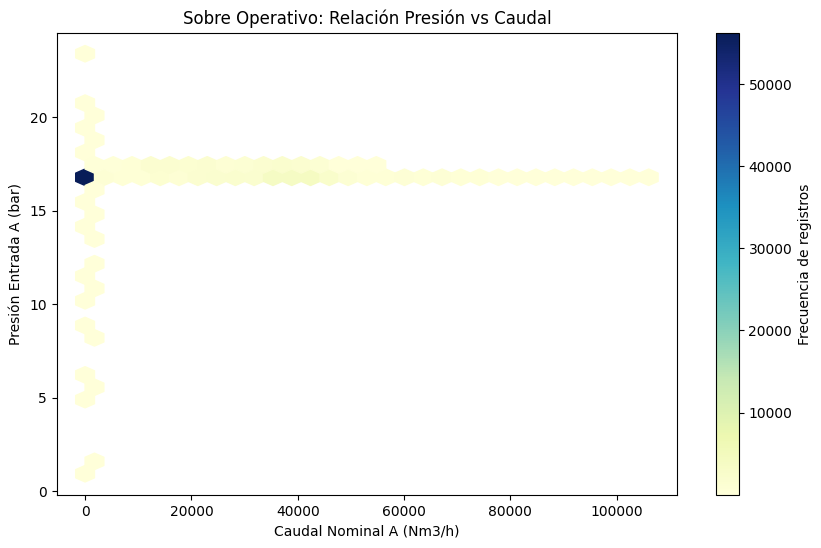

In [12]:
plt.figure(figsize=(10, 6))
# Usamos un scatter con densidad para ver dónde "vive" la ERM
plt.hexbin(df['caudal_nominal_A'], df['presion_in_A'], gridsize=30, cmap='YlGnBu', mincnt=1)
plt.colorbar(label='Frecuencia de registros')
plt.xlabel('Caudal Nominal A (Nm3/h)')
plt.ylabel('Presión Entrada A (bar)')
plt.title('Sobre Operativo: Relación Presión vs Caudal')
plt.show()

4. Análisis de Estacionalidad (Mes a Mes)

C:\Users\braya\AppData\Local\Temp\ipykernel_28008\2594817865.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='mes', y='caudal_nominal_A', data=df, palette='viridis')


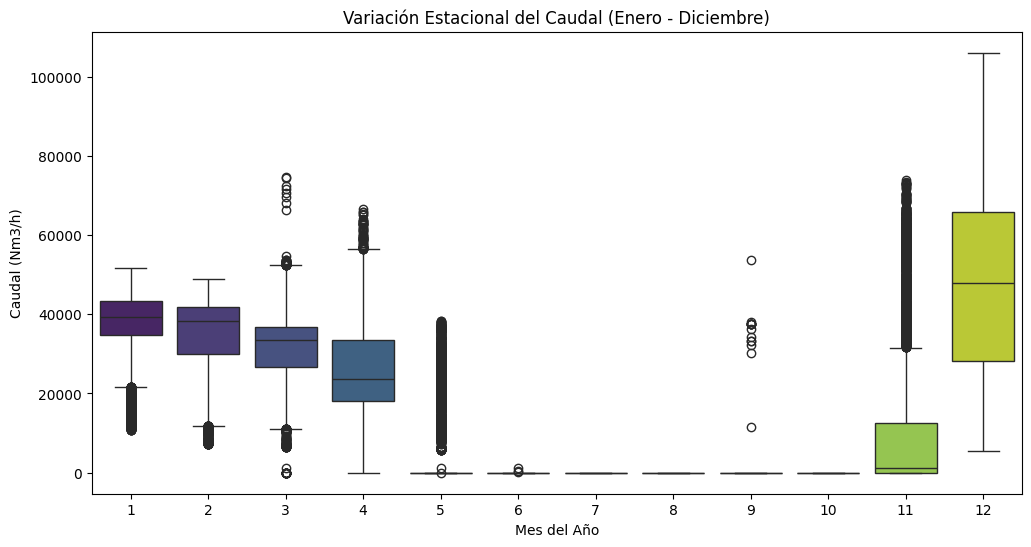

In [13]:
plt.figure(figsize=(12, 6))
df['mes'] = df.index.month
sns.boxplot(x='mes', y='caudal_nominal_A', data=df, palette='viridis')
plt.title('Variación Estacional del Caudal (Enero - Diciembre)')
plt.xlabel('Mes del Año')
plt.ylabel('Caudal (Nm3/h)')
plt.show()

Fase 1: Análisis Descriptivo

Estadísticos Descriptivos de la ERM 400:


,mean,std,min,50%,max
presion_in_A,16.801627,2.012130e-01,0.960315,16.806276,17.592190
presion_in_B,16.802657,2.918895e-01,0.928738,16.810114,17.818346
temperatura_in_A,9.315173,5.072224e+00,-7.736903,8.472405,31.110189
temperatura_in_B,17.833186,7.381107e+00,-9.423908,17.511106,33.797226
caudal_bruto_A,147.995742,7.361528e+01,0.000000,137.725837,535.238037
caudal_bruto_B,7.420816,2.919250e+01,0.000000,0.000000,287.772342
caudal_nominal_A,2477.658921,1.248040e+03,0.000000,2321.163882,8776.635377
caudal_nominal_B,123.559415,4.867819e+02,0.000000,0.000000,4933.588903
caudal_min_diario_A,0.000000,0.000000e+00,0.000000,0.000000,0.000000
caudal_min_diario_B,0.000000,0.000000e+00,0.000000,0.000000,0.000000


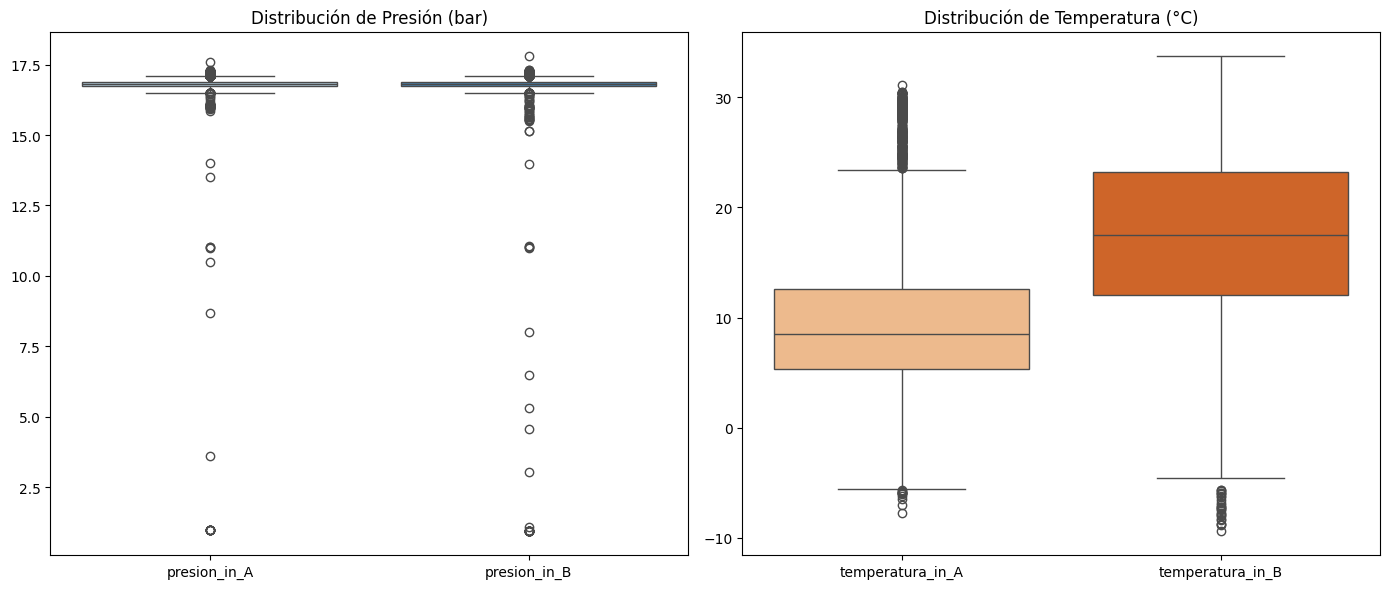

In [11]:
# 1. Estadísticos descriptivos de las variables principales
variables_criticas = ['presion_in_A', 'presion_in_B', 'temperatura_in_A', 'temperatura_in_B',
       'caudal_bruto_A', 'caudal_bruto_B', 'caudal_nominal_A',
       'caudal_nominal_B', 'caudal_min_diario_A', 'caudal_min_diario_B',
       'caudal_max_diario_A', 'caudal_max_diario_B']

"""
variables_criticas = ['presion_in_A', 'presion_in_B', 'presion_in_C', 'temperatura_in_A',
       'temperatura_in_B', 'temperatura_in_C', 'caudal_bruto_A',
       'caudal_bruto_B', 'caudal_bruto_C', 'caudal_nominal_A',
       'caudal_nominal_B', 'caudal_nominal_C', 'caudal_min_diario_A',
       'caudal_min_diario_B', 'caudal_min_diario_C', 'caudal_max_diario_A',
       'caudal_max_diario_B', 'caudal_max_diario_C']
"""
       
desc_stats = df[variables_criticas].describe().T
print("Estadísticos Descriptivos de la ERM 400:")
display(desc_stats[['mean', 'std', 'min', '50%', 'max']])

# 2. Boxplots para visualizar la dispersión y los primeros "Outliers"
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=df[['presion_in_A', 'presion_in_B']], palette="Blues")
plt.title('Distribución de Presión (bar)')

plt.subplot(1, 2, 2)
sns.boxplot(data=df[['temperatura_in_A', 'temperatura_in_B']], palette="Oranges")
plt.title('Distribución de Temperatura (°C)')
plt.tight_layout()
plt.show()

### Fase 2: Análisis de Redundancia y Balance (Línea A vs Línea B)
Enagás usa dos líneas por seguridad. Si funcionan bien, deben ser un espejo la una de la otra.

Correlación Presión A vs C: 0.2819


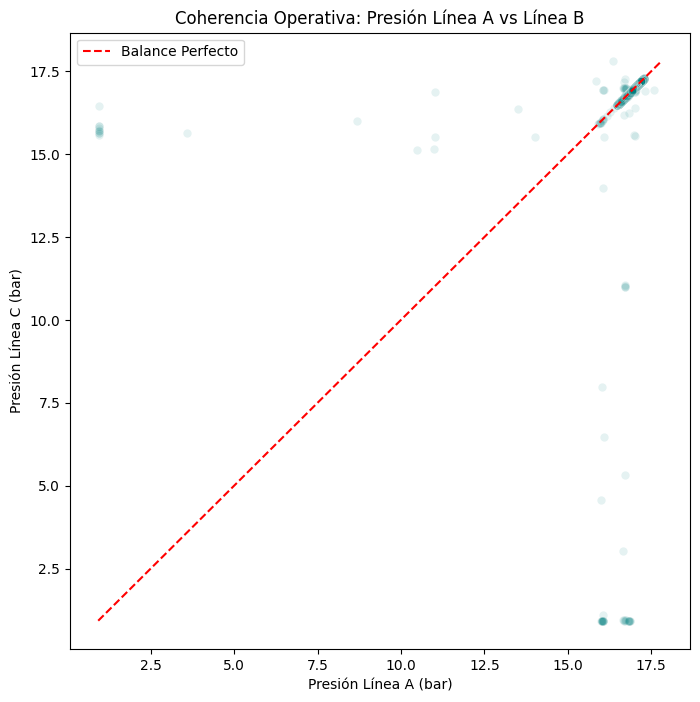

In [12]:
# 1. Correlación de Pearson
corr_ab = df['presion_in_A'].corr(df['presion_in_B'])
print(f"Correlación Presión A vs C: {corr_ab:.4f}")

# 2. Gráfico de dispersión (Scatter) para ver desviaciones
plt.figure(figsize=(8, 8))
sns.scatterplot(x='presion_in_A', y='presion_in_B', data=df, alpha=0.1, color='teal')
# Línea ideal (x=y)
min_val = min(df['presion_in_A'].min(), df['presion_in_B'].min())
max_val = max(df['presion_in_A'].max(), df['presion_in_B'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Balance Perfecto')

plt.title('Coherencia Operativa: Presión Línea A vs Línea B')
plt.xlabel('Presión Línea A (bar)')
plt.ylabel('Presión Línea C (bar)')
plt.legend()
plt.show()

### Fase 3: Perfiles Temporales (La Demanda de Gas)
El consumo de gas no es constante; tiene horas pico (mañana/noche). Esto afecta la presión.

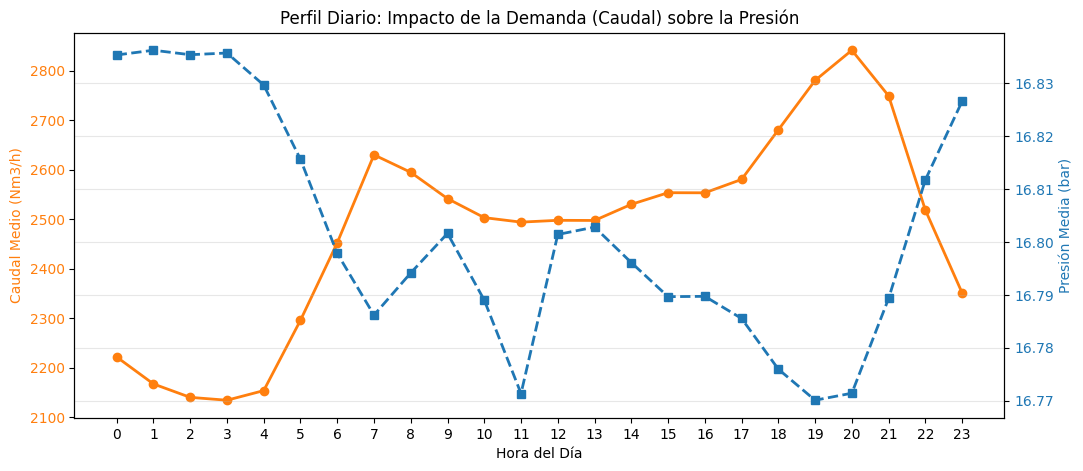

In [13]:
# Crear variables temporales temporales (solo para análisis)
df_temp = df.copy()
df_temp['Hora'] = df_temp.index.hour
df_temp['Mes'] = df_temp.index.month

# Agrupar por hora del día
perfil_diario = df_temp.groupby('Hora')[['caudal_nominal_A', 'presion_in_A']].mean()

fig, ax1 = plt.subplots(figsize=(12, 5))

# Eje Y izquierdo: Caudal
color = 'tab:orange'
ax1.set_xlabel('Hora del Día')
ax1.set_ylabel('Caudal Medio (Nm3/h)', color=color)
ax1.plot(perfil_diario.index, perfil_diario['caudal_nominal_A'], color=color, marker='o', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

# Eje Y derecho: Presión
ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Presión Media (bar)', color=color)
ax2.plot(perfil_diario.index, perfil_diario['presion_in_A'], color=color, marker='s', linestyle='--', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Perfil Diario: Impacto de la Demanda (Caudal) sobre la Presión')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

Analiza si hay caídas ligeras de presión cuando el caudal alcanza sus picos máximos. Esto demuestra que entiendes la termodinámica de la estación.

## Proceso de Etiquetacion del Target Anomalia

### Metodo 1: etiquetación con AVISOS SAP (SCADA vs Avisos SAP)

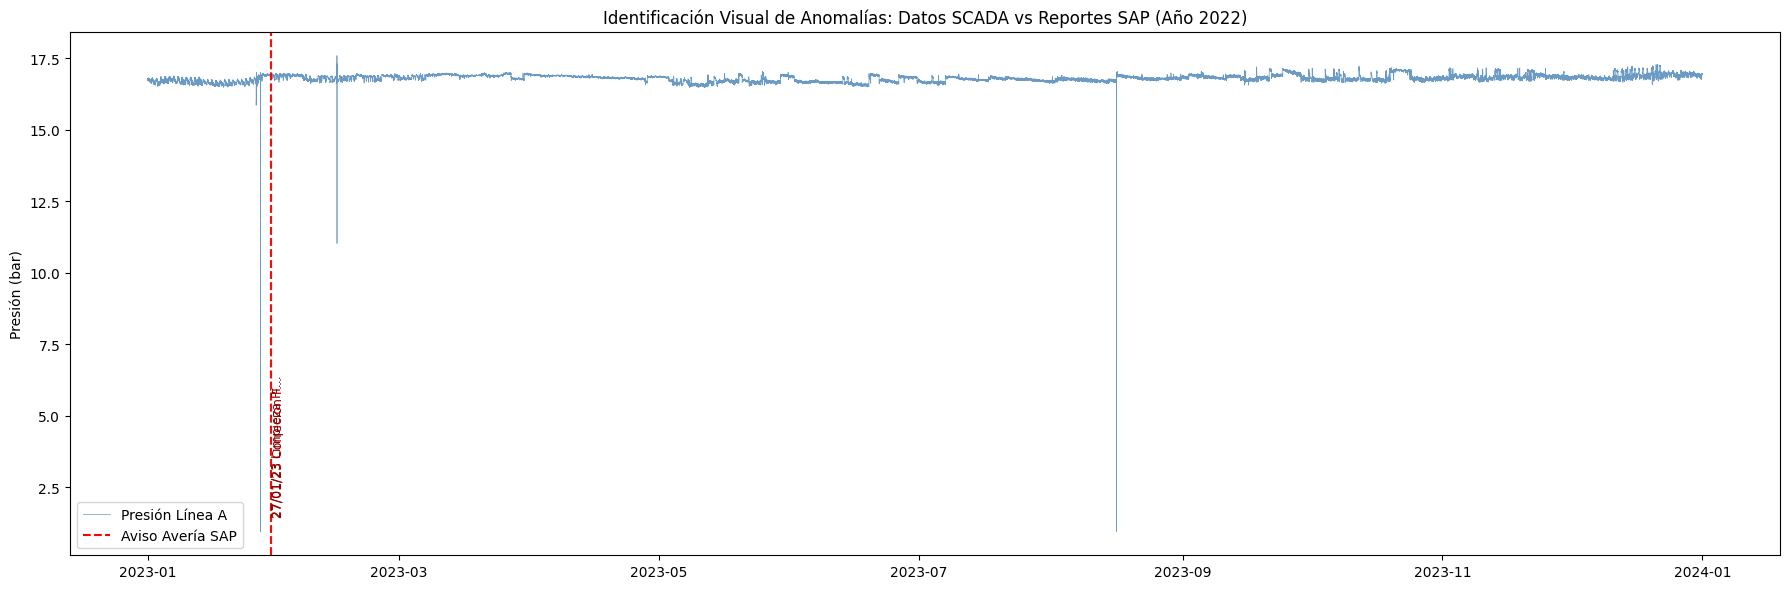

In [14]:
# 1. Filtrar los avisos de SAP para que coincidan con el año de nuestro dataset
df_sap_2022 = df_sap[(df_sap['datetime_fallo'] >= df.index.min()) & (df_sap['datetime_fallo'] <= df.index.max())]

# 2. Gráfico histórico de presión con marcas de mantenimiento
plt.figure(figsize=(18, 6))
plt.plot(df.index, df['presion_in_A'], label='Presión Línea A', color='steelblue', alpha=0.8, linewidth=0.5)

# 3. Dibujar líneas verticales para cada avería de SAP
for idx, row in df_sap_2022.iterrows():
    plt.axvline(x=row['datetime_fallo'], color='red', linestyle='--', linewidth=1.5, alpha=0.8)
    
    # Usamos 'DESCRIPCIÓN AVISO'
    # Convertimos a string por si hay algún valor nulo (NaN)
    texto_aviso = str(row['DESCRIPCIÓN AVISO'])
    
    # Etiqueta con el texto del aviso (recortado a 20 caracteres para que no ocupe mucho)
    plt.text(row['datetime_fallo'], df['presion_in_A'].min() + 0.5, texto_aviso[:20]+'...', 
             rotation=90, color='darkred', fontsize=9, verticalalignment='bottom')

# Añadir una leyenda fantasma para las líneas rojas
plt.plot([], [], color='red', linestyle='--', label='Aviso Avería SAP')

plt.title('Identificación Visual de Anomalías: Datos SCADA vs Reportes SAP (Año 2022)')
plt.ylabel('Presión (bar)')
plt.legend()
plt.tight_layout()
plt.show()

Fase 5: Zoom a una Anomalía (Micro-análisis)

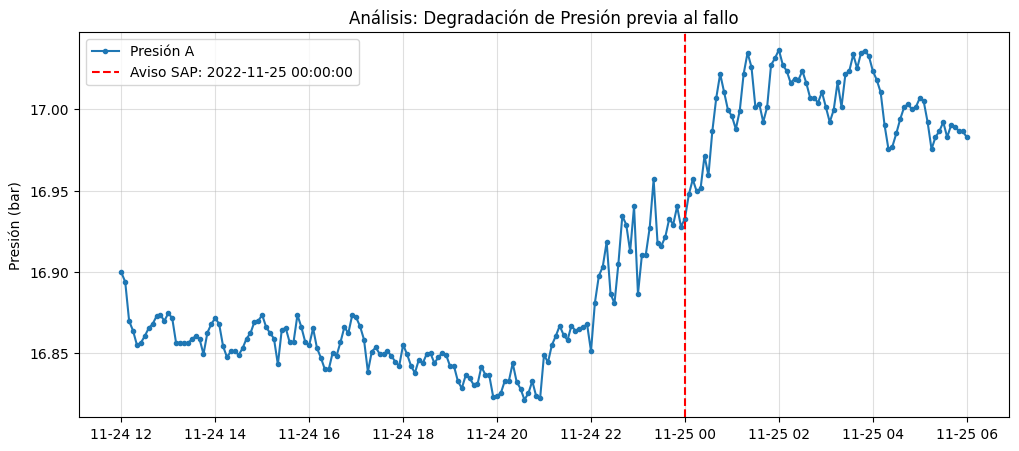

In [18]:
if not df_sap_2022.empty:
    # Tomamos el primer aviso del 2022 (ej. la de febrero)
    fecha_aviso = df_sap_2022['datetime_fallo'].iloc[0]
    
    # Ventana de tiempo: 12 horas antes y 6 horas después
    inicio_ventana = fecha_aviso - pd.Timedelta(hours=12)
    fin_ventana = fecha_aviso + pd.Timedelta(hours=6)
    
    df_zoom = df.loc[inicio_ventana:fin_ventana]
    
    plt.figure(figsize=(12, 5))
    plt.plot(df_zoom.index, df_zoom['presion_in_A'], label='Presión A', marker='.')
    plt.axvline(fecha_aviso, color='red', linestyle='--', label=f'Aviso SAP: {fecha_aviso}')
    
    plt.title('Análisis: Degradación de Presión previa al fallo')
    plt.ylabel('Presión (bar)')
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.show()

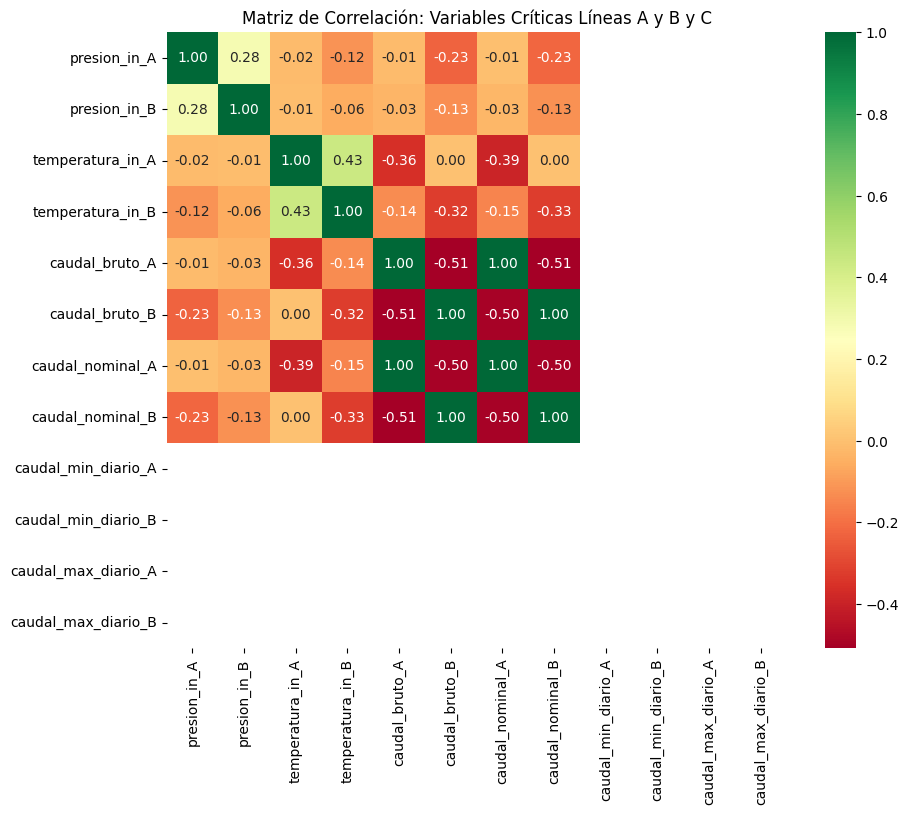

In [15]:
plt.figure(figsize=(10, 8))


corr_matrix = df[['presion_in_A', 'presion_in_B', 'temperatura_in_A', 'temperatura_in_B',
       'caudal_bruto_A', 'caudal_bruto_B', 'caudal_nominal_A',
       'caudal_nominal_B', 'caudal_min_diario_A', 'caudal_min_diario_B',
       'caudal_max_diario_A', 'caudal_max_diario_B']].corr()

"""
corr_matrix = df[['presion_in_A', 'presion_in_B', 'presion_in_C', 'temperatura_in_A',
       'temperatura_in_B', 'temperatura_in_C', 'caudal_bruto_A',
       'caudal_bruto_B', 'caudal_bruto_C', 'caudal_nominal_A',
       'caudal_nominal_B', 'caudal_nominal_C', 'caudal_min_diario_A',
       'caudal_min_diario_B', 'caudal_min_diario_C', 'caudal_max_diario_A',
       'caudal_max_diario_B', 'caudal_max_diario_C']].corr()
"""

sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Matriz de Correlación: Variables Críticas Líneas A y B y C')
plt.show()

In [16]:
# Procesamiento de tiempo o fecha del fallo
df_sap[['Inicio avería','Ini.avería (h)','Inicio deseado','datetime_fallo']]

,Inicio avería,Ini.avería (h),Inicio deseado,datetime_fallo
0,NaN,00:00:00,2022-02-06,2022-02-06 00:00:00
1,NaN,00:00:00,2022-02-06,2022-02-06 00:00:00
2,NaN,00:00:00,2023-01-30,2023-01-30 00:00:00
3,NaN,00:00:00,2023-01-30,2023-01-30 00:00:00
4,NaN,00:00:00,2025-07-18,2025-07-18 00:00:00
5,NaN,00:00:00,2022-08-24,2022-08-24 00:00:00
6,NaN,00:00:00,2021-10-18,2021-10-18 00:00:00
7,2022-02-10,12:24:23,2022-02-10,2022-02-10 12:24:23
8,2021-10-20,09:49:48,2021-10-20,2021-10-20 09:49:48
9,2022-08-24,12:47:26,2022-08-24,2022-08-24 12:47:26


## Etiquetado del ANOMALIA USANDO AVISOS SAP

In [17]:
df['is_anomaly'] = 0
# Ahora el etiquetado será mucho más preciso
for fecha_exacta in df_sap['datetime_fallo']:
    # 24 HOUR ATRAS,  y 10 minutos adelante
    mask = (df.index >= fecha_exacta - pd.Timedelta(hours=24)) & \
           (df.index <= fecha_exacta + pd.Timedelta(minutes=10))
    df.loc[mask, 'is_anomaly'] = 1
print(f"Registros etiquetados como anomalía real: {df['is_anomaly'].sum()}")

Registros etiquetados como anomalía real: 291


In [18]:
# 1. Inicializamos la columna
df['tipo_fallo_detalle'] = "Normal"

# 2. Solo para las filas donde is_anomaly es 1, buscamos su descripción en df_sap
for _, row_sap in df_sap.iterrows():
    # Buscamos en el df principal las filas que coincidan con el periodo de este aviso
    fecha_f = row_sap['datetime_fallo']
    desc = str(row_sap['DESCRIPCIÓN AVISO'])
    
    # Marcamos el detalle solo donde is_anomaly ya es 1 
    # y la fecha coincide con este aviso específico
    mask_este_aviso = (df['is_anomaly'] == 1) & \
                      (df.index >= fecha_f - pd.Timedelta(hours=24)) & \
                      (df.index <= fecha_f + pd.Timedelta(minutes=10))
    
    df.loc[mask_este_aviso, 'tipo_fallo_detalle'] = f"SAP: {desc}"

# Verificamos qué nombres de fallos han quedado
print(df[df['is_anomaly'] == 1]['tipo_fallo_detalle'].value_counts())

tipo_fallo_detalle
SAP: 27/01/23 Limpieza Pilotos ERM_400    291
Name: count, dtype: int64


In [19]:
df["is_anomaly"].value_counts()

is_anomaly
0    104818
1       291
Name: count, dtype: int64

### Validación de "Ceros" en la Ventana de 24h

### Auditoría de Ceros en Ventana de Anomalía
Vamos a calcular exactamente qué porcentaje de ceros hay en cada variable crítica solo dentro de las filas que has marcado como anomalía. Esto confirmará si el fallo detectado por SAP tiene señal física que el modelo pueda aprender.

In [20]:
df.columns

Index(['presion_in_A', 'presion_in_B', 'temperatura_in_A', 'temperatura_in_B',
       'caudal_bruto_A', 'caudal_bruto_B', 'caudal_nominal_A',
       'caudal_nominal_B', 'caudal_min_diario_A', 'caudal_min_diario_B',
       'caudal_max_diario_A', 'caudal_max_diario_B', 'turno',
       'delta_presion_temp', 'is_anomaly', 'tipo_fallo_detalle'],
      dtype='str')

In [21]:
# Variables críticas de la Línea A
variables_analisis = ['presion_in_A', 'temperatura_in_A', 'caudal_bruto_A', 'caudal_nominal_A', 'caudal_min_diario_A', 'caudal_max_diario_A']

#variables_analisis = ['presion_in_C', 'temperatura_in_C', 'caudal_bruto_C', 'caudal_nominal_C', 'caudal_min_diario_C', 'caudal_max_diario_C']

print("--- Auditoría de Pureza en Ventana de Anomalía (SAP) ---")
df_anomalos = df[df['is_anomaly'] == 1]

for var in variables_analisis:
    total_obs = len(df_anomalos)
    ceros = (df_anomalos[var] == 0).sum()
    pct_ceros = (ceros / total_obs) * 100
    print(f"Variable {var:.<20} | Ceros: {ceros} ({pct_ceros:.2f}%)")

--- Auditoría de Pureza en Ventana de Anomalía (SAP) ---
Variable presion_in_A........ | Ceros: 0 (0.00%)
Variable temperatura_in_A.... | Ceros: 0 (0.00%)
Variable caudal_bruto_A...... | Ceros: 0 (0.00%)
Variable caudal_nominal_A.... | Ceros: 0 (0.00%)
Variable caudal_min_diario_A. | Ceros: 291 (100.00%)
Variable caudal_max_diario_A. | Ceros: 0 (0.00%)


## 1. Isolation Forest para detectar "Anomalias" Y Ver cuantos concuerdan con los fallos reales de SAP AVISOS

In [22]:
df["is_anomaly"].value_counts()

is_anomaly
0    104818
1       291
Name: count, dtype: int64

In [23]:
from sklearn.ensemble import IsolationForest

# Seleccionamos variables clave según el Word (Presión + Caudal)
features = ['presion_in_A', 'temperatura_in_A',
            'caudal_nominal_A', 'caudal_bruto_A','caudal_max_diario_A']

# Ajustamos el Isolation Forest con la visión completa de la ERM
#n_estimators=100: Crea 100 árboles de decisión aleatorios.
#contamination=0.02: Tú le estás diciendo: "Sé que aproximadamente el 2% de mis datos son raros o fallos". El algoritmo ajusta el umbral para marcar ese 2% más raro.
#random_state=42: Para que siempre que corras el código obtengas las mismas anomalías.
# tamaño de la muestra (max_samples)
clf = IsolationForest(contamination=0.02, max_samples=256,random_state=42) 
df['anomaly_IF'] = clf.fit_predict(df[features])

# Convertir: -1 es anomalía en IF, lo pasamos a 1
df['anomaly_IF'] = df['anomaly_IF'].map({1: 0, -1: 1})

# 3. Cálculo de Concordancia (Matriz de Confusión)
# Comparamos is_anomaly (SAP) contra anomaly_IF (Modelo)
concordancia = df[(df['is_anomaly'] == 1) & (df['anomaly_IF'] == 1)].shape[0]
total_sap = df['is_anomaly'].sum()
porcentaje_exito = (concordancia / total_sap) * 100

print(f"--- RESULTADOS DE VALIDACIÓN ---")
print(f"Total registros SAP (Anomalías Reales): {total_sap}")
print(f"Anomalías SAP detectadas por el IF: {concordancia}")
print(f"Precisión de detección (Recall): {porcentaje_exito:.2f}%")

# 4. Target Final Consolidado
df['target_final'] = ((df['is_anomaly'] == 1) | (df['anomaly_IF'] == 1)).astype(int)

--- RESULTADOS DE VALIDACIÓN ---
Total registros SAP (Anomalías Reales): 291
Anomalías SAP detectadas por el IF: 0
Precisión de detección (Recall): 0.00%


In [24]:
df["anomaly_IF"].value_counts()

anomaly_IF
0    103006
1      2103
Name: count, dtype: int64

In [25]:
pd.options.display.max_columns = None
pd.options.display.max_rows = None
base_path = r"C:\Users\braya\Documents\TFM_UCM_Enagas\tfm_enagas"
processed_path = os.path.join(base_path, "data", "processed")

df_1s_if=df[df["anomaly_IF"]==1]
df_1s_if.to_csv(os.path.join(processed_path, "df_sap_erm_400_limpio_IF_target_1s.csv"), index=False)

## 1. Análisis Técnico: Mapeo de Anomalías IF a Modos de Fallo SCADA
Podemos automatizar esta columna "Fallo_SCADA" con el siguiente análisis sobre los registros anómalos:

In [26]:
df_1s_if.head(3)

,presion_in_A,presion_in_B,temperatura_in_A,temperatura_in_B,caudal_bruto_A,caudal_bruto_B,caudal_nominal_A,caudal_nominal_B,caudal_min_diario_A,caudal_min_diario_B,caudal_max_diario_A,caudal_max_diario_B,turno,delta_presion_temp,is_anomaly,tipo_fallo_detalle,anomaly_IF,target_final
datetime,,,,,,,,,,,,,,,,,,
2023-01-02 18:20:00,16.579483,16.589111,12.620158,9.607299,0.0,119.075600,0.0,1964.091664,0,0,64135.745844,13746.320905,Tarde,0.004055,0,Normal,1,1
2023-01-02 18:25:00,16.581680,16.590967,12.626925,10.117414,0.0,119.145738,0.0,1961.401322,0,0,64135.745844,13746.320905,Tarde,0.002197,0,Normal,1,1
2023-01-02 18:30:00,16.566820,16.576109,12.630707,10.631184,0.0,121.573264,0.0,1995.285601,0,0,64135.745844,13746.320905,Tarde,0.014860,0,Normal,1,1


## Veamos si las anomalías detectadas por el IF, corresponde a algunas reglas de WORD SCADA

In [27]:
import pandas as pd
import numpy as np

# Cargamos los datos donde el IF detectó algo
df_if = pd.read_csv(r'C:\Users\braya\Documents\TFM_UCM_Enagas\tfm_enagas\data\processed\df_sap_erm_400_limpio_IF_target_1s.csv')

def clasificar_fallo_scada(row):
    if row['anomaly_IF'] == 0:
        return "Normal"
    
    # Lógica 1: Caudal 0 con presión inestable (Pérdida de estanqueidad)
    if row['caudal_bruto_A'] <= 0.1 and row['delta_presion_temp'] > 0.01:
        return "Pastilla desgastada (Falta Estanqueidad)"
    
    # Lógica 2: Fluctuaciones (Basado en Delta Presion alto con caudal alto)
    if row['delta_presion_temp'] > 0.05:
        return "Membrana deformada / Anillos guía sucios"
    
    # Lógica 3: Inestabilidad de flujo
    if row['caudal_nominal_A'] > 0 and row['caudal_bruto_A'] < 10:
        return "Obturador sucio / Filtro colmatado"
    
    return "Anomalía Estadística no clasificada"

# Creamos la nueva columna
df_if['fallo_especifico_scada'] = df_if.apply(clasificar_fallo_scada, axis=1)

# Ver resultados de la clasificación
print(df_if[df_if['anomaly_IF']==1]['fallo_especifico_scada'].value_counts())

fallo_especifico_scada
Anomalía Estadística no clasificada         1826
Membrana deformada / Anillos guía sucios     175
Pastilla desgastada (Falta Estanqueidad)      88
Obturador sucio / Filtro colmatado            14
Name: count, dtype: int64


### Propuesta de "Lógica Inversa": 
Etiquetado basado en Reglas de Experto
Tu idea de usar las 3 reglas del manual SCADA para crear etiquetas es excelente y es lo que en IA llamamos Sistemas Basados en Reglas (Rule-Based Systems) o Etiquetado Programático.

In [28]:
df.head(2)

,presion_in_A,presion_in_B,temperatura_in_A,temperatura_in_B,caudal_bruto_A,caudal_bruto_B,caudal_nominal_A,caudal_nominal_B,caudal_min_diario_A,caudal_min_diario_B,caudal_max_diario_A,caudal_max_diario_B,turno,delta_presion_temp,is_anomaly,tipo_fallo_detalle,anomaly_IF,target_final
datetime,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,16.784145,16.792011,11.613059,4.581303,0.0,49.199109,0.0,841.179544,0,0,64135.745844,13746.320905,Noche,NaN,0,Normal,0,0
2023-01-01 00:05:00,16.760601,16.767427,11.588407,13.210862,0.0,41.060760,0.0,677.303323,0,0,64135.745844,13746.320905,Noche,0.023544,0,Normal,0,0


In [34]:
# Aplicar reglas de experto SCADA a todo el dataset
df['is_scada_anomaly'] = 0
df['tipo_fallo_scada'] = 'Normal'

# Regla 1: Pastilla desgastada (Falta Estanqueidad)
mask_estanqueidad = (df['caudal_bruto_A'] <= 0.1) & (df['delta_presion_temp'] > 0.01)
df.loc[mask_estanqueidad, 'is_scada_anomaly'] = 1
df.loc[mask_estanqueidad, 'tipo_fallo_scada'] = 'Pastilla desgastada'

# Regla 2: Membrana deformada / Anillos guía sucios
# Añadimos: solo si no ha sido marcada por la Regla 1
mask_fluctuacion = (df['delta_presion_temp'] > 0.05) & (df['is_scada_anomaly'] == 0)
df.loc[mask_fluctuacion, 'is_scada_anomaly'] = 1
df.loc[mask_fluctuacion, 'tipo_fallo_scada'] = 'Membrana/Anillos sucios'

# Regla 3: Obturador sucio / Filtro colmatado
# Añadimos: solo si no ha sido marcada por la Regla 1 o 2
mask_obturador = (df['caudal_nominal_A'] > 0) & (df['caudal_bruto_A'] < 10) & (df['is_scada_anomaly'] == 0)
df.loc[mask_obturador, 'is_scada_anomaly'] = 1
df.loc[mask_obturador, 'tipo_fallo_scada'] = 'Obturador sucio/Filtro'

# Nuevo Target Consolidado: SAP + REGLAS EXPERTAS
df['target_final_v2'] = ((df['is_anomaly'] == 1) | (df['is_scada_anomaly'] == 1)).astype(int)

print(f"Anomalías por SAP: {df['is_anomaly'].sum()}")
print(f"Anomalías por Reglas SCADA: {df['is_scada_anomaly'].sum()}")
print(f"Total Anomalías para entrenar el modelo: {df['target_final_v2'].sum()}")

Anomalías por SAP: 291
Anomalías por Reglas SCADA: 8157
Total Anomalías para entrenar el modelo: 8448


In [35]:
df.head(2)

,presion_in_A,presion_in_B,temperatura_in_A,temperatura_in_B,caudal_bruto_A,caudal_bruto_B,caudal_nominal_A,caudal_nominal_B,caudal_min_diario_A,caudal_min_diario_B,caudal_max_diario_A,caudal_max_diario_B,turno,delta_presion_temp,is_anomaly,tipo_fallo_detalle,anomaly_IF,target_final,is_scada_anomaly,target_final_v2,tipo_fallo_scada
datetime,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,16.784145,16.792011,11.613059,4.581303,0.0,49.199109,0.0,841.179544,0,0,64135.745844,13746.320905,Noche,NaN,0,Normal,0,0,0,0,Normal
2023-01-01 00:05:00,16.760601,16.767427,11.588407,13.210862,0.0,41.060760,0.0,677.303323,0,0,64135.745844,13746.320905,Noche,0.023544,0,Normal,0,0,1,1,Pastilla desgastada


In [36]:
# 1. Análisis de Concordancia (Intersección)
interseccion = df[(df['is_anomaly'] == 1) & (df['is_scada_anomaly'] == 1)].shape[0]
solo_sap = df[(df['is_anomaly'] == 1) & (df['is_scada_anomaly'] == 0)].shape[0]
solo_scada = df[(df['is_anomaly'] == 0) & (df['is_scada_anomaly'] == 1)].shape[0]

print("--- ANÁLISIS 1: CONCORDANCIA SAP VS SCADA ---")
print(f"Anomalías detectadas por AMBOS (Concordancia): {interseccion}")
print(f"Anomalías que SOLO SAP detectó: {solo_sap}")
print(f"Anomalías que SOLO las Reglas SCADA detectaron: {solo_scada}")
print("-" * 40)

# 2. Análisis de Clasificación de Fallos SCADA
# Vamos a ver qué reglas de SCADA están saltando más
estanqueidad = df[mask_estanqueidad].shape[0]
fluctuacion = df[mask_fluctuacion].shape[0]
obturador = df[mask_obturador].shape[0]

print("--- ANÁLISIS 2: DISTRIBUCIÓN DE FALLOS SCADA (ERM_400) ---")
print(f"Registros con 'Pastilla desgastada' (Caudal 0 + Salto P): {estanqueidad}")
print(f"Registros con 'Membrana/Anillos sucios' (Salto P brusco): {fluctuacion}")
print(f"Registros con 'Obturador sucio/Filtro' (Caudal nominal vs bruto): {obturador}")
print(f"SUMA TOTAL REGLAS: {estanqueidad + fluctuacion + obturador}")
print(f"TOTAL is_scada_anomaly: {df['is_scada_anomaly'].sum()}")

--- ANÁLISIS 1: CONCORDANCIA SAP VS SCADA ---
Anomalías detectadas por AMBOS (Concordancia): 0
Anomalías que SOLO SAP detectó: 291
Anomalías que SOLO las Reglas SCADA detectaron: 8157
----------------------------------------
--- ANÁLISIS 2: DISTRIBUCIÓN DE FALLOS SCADA (ERM_400) ---
Registros con 'Pastilla desgastada' (Caudal 0 + Salto P): 4370
Registros con 'Membrana/Anillos sucios' (Salto P brusco): 3756
Registros con 'Obturador sucio/Filtro' (Caudal nominal vs bruto): 31
SUMA TOTAL REGLAS: 8157
TOTAL is_scada_anomaly: 8157


In [37]:
# Variables a analizar de la Línea A
variables_A = ['presion_in_A', 'temperatura_in_A', 'caudal_bruto_A', 'caudal_nominal_A']

print("--- AUDITORÍA DE PUREZA: ETIQUETAS POR REGLAS SCADA ---")
# Filtramos solo las filas que marcaste con las reglas de SCADA
df_solo_scada = df[df['is_scada_anomaly'] == 1]

for var in variables_A:
    total_obs = len(df_solo_scada)
    ceros = (df_solo_scada[var] == 0).sum()
    pct_ceros = (ceros / total_obs) * 100
    print(f"Variable {var:.<25} | Ceros: {ceros} ({pct_ceros:.2f}%)")

--- AUDITORÍA DE PUREZA: ETIQUETAS POR REGLAS SCADA ---
Variable presion_in_A............. | Ceros: 0 (0.00%)
Variable temperatura_in_A......... | Ceros: 0 (0.00%)
Variable caudal_bruto_A........... | Ceros: 4369 (53.56%)
Variable caudal_nominal_A......... | Ceros: 4369 (53.56%)


In [38]:
df["is_scada_anomaly"].value_counts()

is_scada_anomaly
0    96952
1     8157
Name: count, dtype: int64

In [40]:
df.head()

,presion_in_A,presion_in_B,temperatura_in_A,temperatura_in_B,caudal_bruto_A,caudal_bruto_B,caudal_nominal_A,caudal_nominal_B,caudal_min_diario_A,caudal_min_diario_B,caudal_max_diario_A,caudal_max_diario_B,turno,delta_presion_temp,is_anomaly,tipo_fallo_detalle,anomaly_IF,target_final,is_scada_anomaly,target_final_v2,tipo_fallo_scada
datetime,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,16.784145,16.792011,11.613059,4.581303,0.0,49.199109,0.0,841.179544,0,0,64135.745844,13746.320905,Noche,NaN,0,Normal,0,0,0,0,Normal
2023-01-01 00:05:00,16.760601,16.767427,11.588407,13.210862,0.0,41.060760,0.0,677.303323,0,0,64135.745844,13746.320905,Noche,0.023544,0,Normal,0,0,1,1,Pastilla desgastada
2023-01-01 00:10:00,16.730278,16.738071,11.562312,16.203283,0.0,42.931357,0.0,698.337504,0,0,64135.745844,13746.320905,Noche,0.030323,0,Normal,0,0,1,1,Pastilla desgastada
2023-01-01 00:15:00,16.720991,16.728420,11.533041,14.399950,0.0,49.035714,0.0,802.273913,0,0,64135.745844,13746.320905,Noche,0.009287,0,Normal,0,0,0,0,Normal
2023-01-01 00:20:00,16.740030,16.746996,11.522590,11.267754,0.0,52.958340,0.0,878.008174,0,0,64135.745844,13746.320905,Noche,0.019039,0,Normal,0,0,1,1,Pastilla desgastada


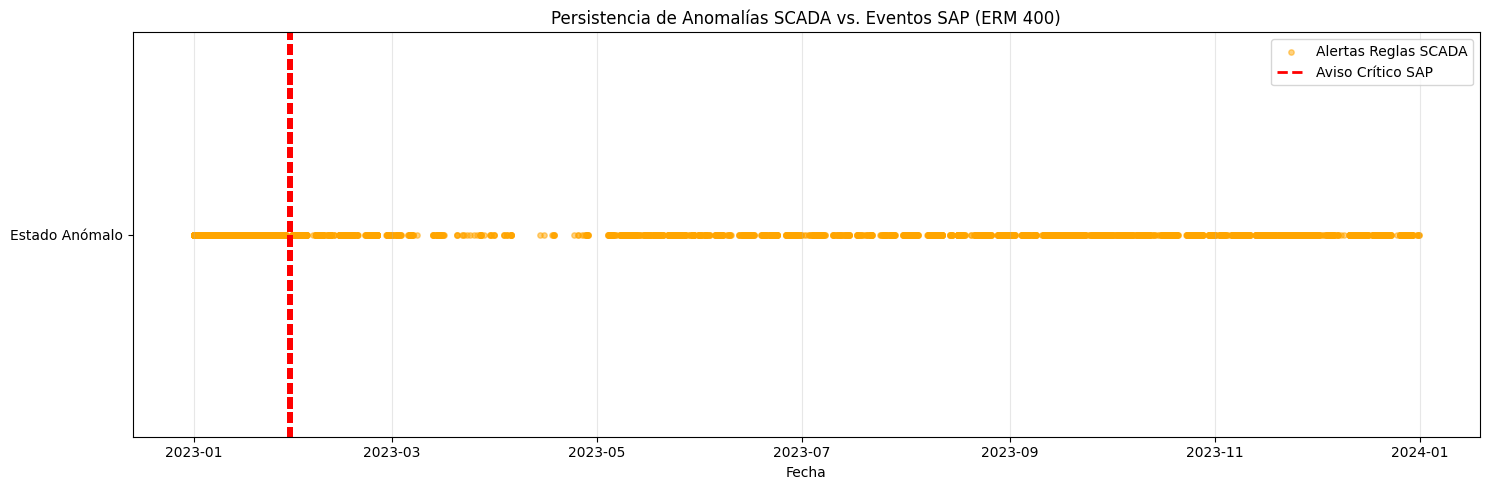

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# 1. Graficar Anomalías SCADA (Reglas)
anomalias_scada = df[df['is_scada_anomaly'] == 1]
plt.scatter(anomalias_scada.index, [1] * len(anomalias_scada), 
            alpha=0.5, s=15, color='orange', label='Alertas Reglas SCADA')

# 2. Graficar Avisos SAP (Sin duplicar leyenda)
avisos_sap = df[df['is_anomaly'] == 1]
for i, fecha in enumerate(avisos_sap.index):
    # Solo añadimos el label a la primera línea roja que encuentre
    label_sap = 'Aviso Crítico SAP' if i == 0 else ""
    plt.axvline(x=fecha, color='red', linestyle='--', linewidth=2, label=label_sap)

plt.title('Persistencia de Anomalías SCADA vs. Eventos SAP (ERM 400)')
plt.ylim(0.5, 1.5)
plt.yticks([1], ['Estado Anómalo'])
plt.xlabel('Fecha')
plt.legend(loc='upper right', frameon=True)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Opción 1: Subplots con Matplotlib

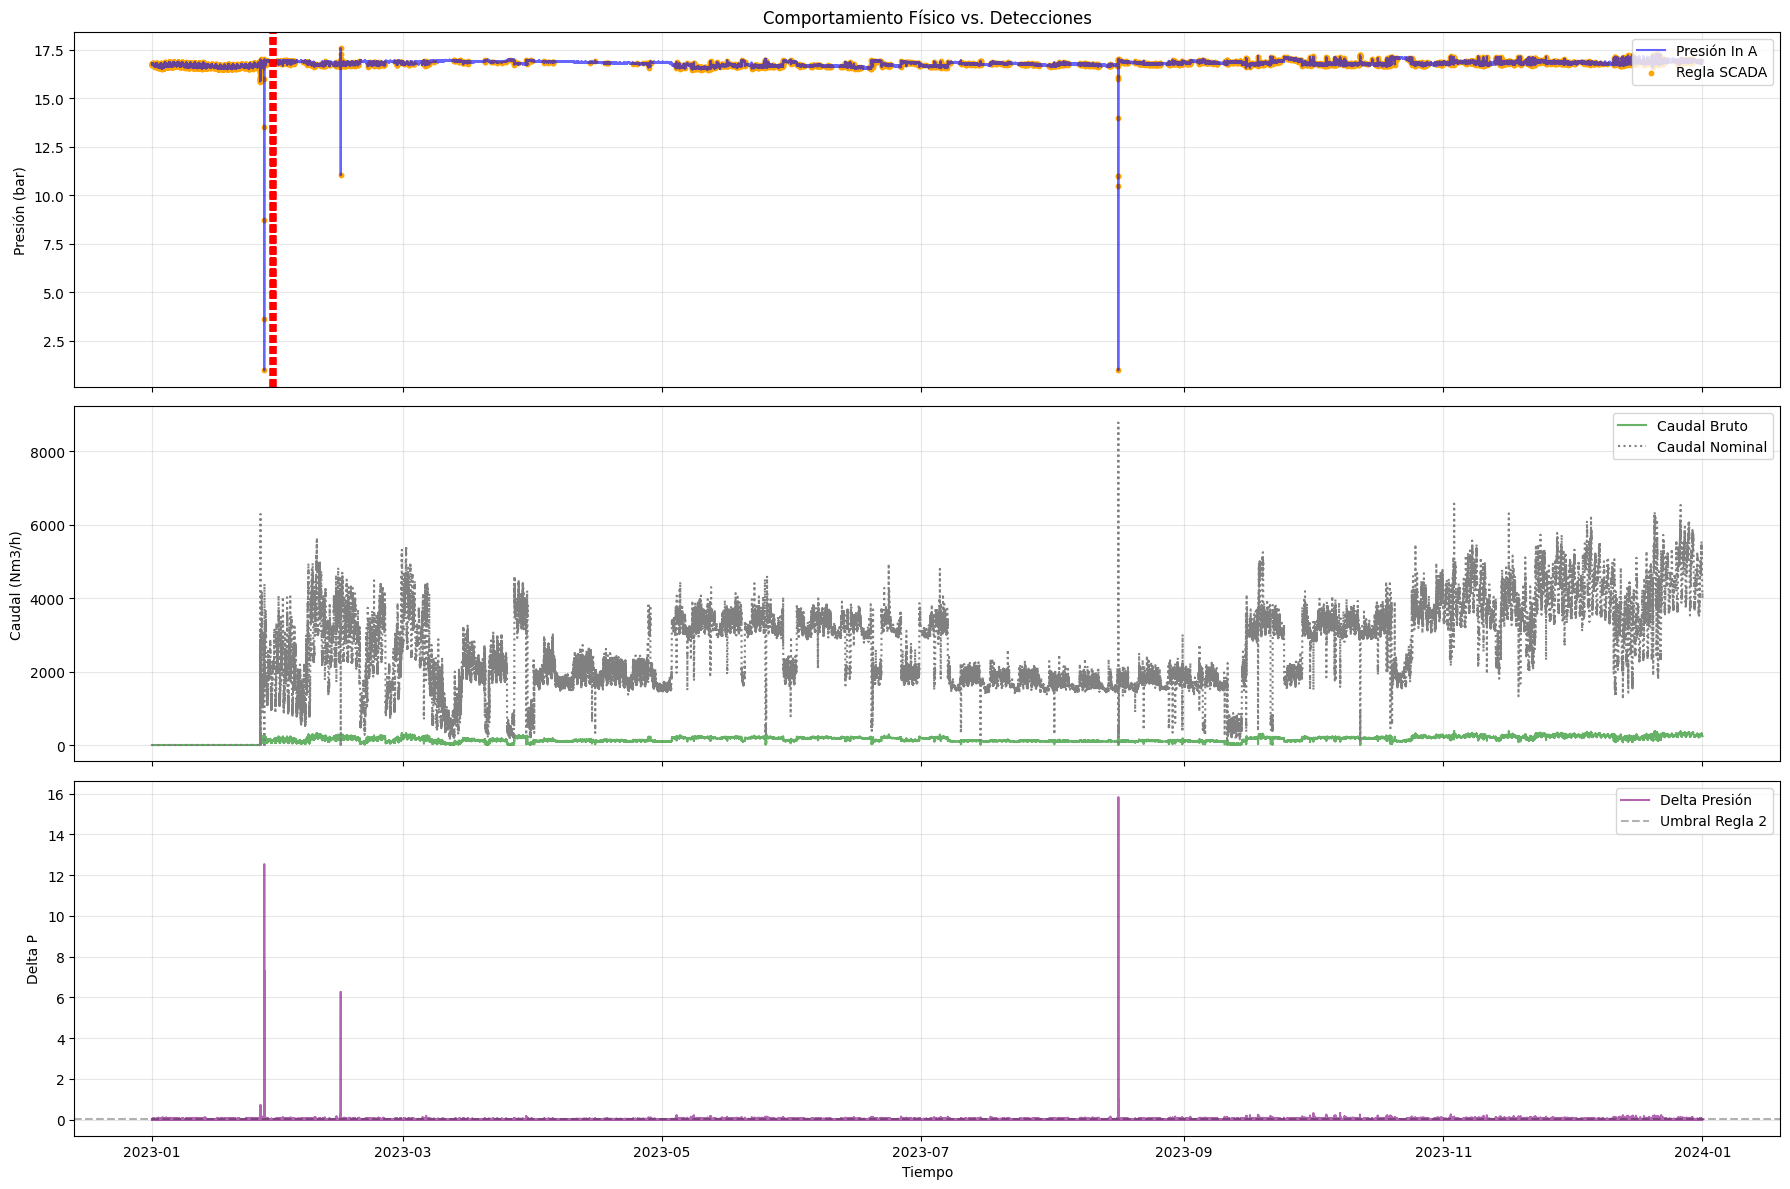

In [41]:
import matplotlib.pyplot as plt

# Creamos 3 subplots que comparten el eje X (el tiempo)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

# 1. Gráfico de Presión y Anomalías
ax1.plot(df.index, df['presion_in_A'], color='blue', alpha=0.6, label='Presión In A')
ax1.set_ylabel('Presión (bar)')
ax1.set_title('Comportamiento Físico vs. Detecciones')

# Dibujar avisos SAP y SCADA sobre la presión
for fecha in df[df['is_anomaly'] == 1].index:
    ax1.axvline(x=fecha, color='red', linestyle='--', alpha=0.7)
    
anom_scada = df[df['is_scada_anomaly'] == 1]
ax1.scatter(anom_scada.index, anom_scada['presion_in_A'], color='orange', s=10, label='Regla SCADA')

# 2. Gráfico de Caudal
ax2.plot(df.index, df['caudal_bruto_A'], color='green', alpha=0.6, label='Caudal Bruto')
ax2.plot(df.index, df['caudal_nominal_A'], color='gray', linestyle=':', label='Caudal Nominal')
ax2.set_ylabel('Caudal (Nm3/h)')

# 3. Gráfico de Delta Presión (donde saltan la mayoría de reglas)
ax3.plot(df.index, df['delta_presion_temp'], color='purple', alpha=0.6, label='Delta Presión')
ax3.axhline(y=0.05, color='black', linestyle='--', alpha=0.3, label='Umbral Regla 2')
ax3.set_ylabel('Delta P')
ax3.set_xlabel('Tiempo')

# Ajustes finales
for ax in [ax1, ax2, ax3]:
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Opción 2: Gráfico Interactivo con Plotly

In [44]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Crear subplots interactivos
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, 
                    vertical_spacing=0.05,
                    subplot_titles=("Presión y Anomalías", "Caudal"))

# Añadir Presión
fig.add_trace(go.Scatter(x=df.index, y=df['presion_in_A'], name="Presión", line=dict(color='blue')), row=1, col=1)

# Añadir Anomalías SCADA (puntos)
anom_scada = df[df['is_scada_anomaly'] == 1]
fig.add_trace(go.Scatter(x=anom_scada.index, y=anom_scada['presion_in_A'], 
                         mode='markers', name='Fallo SCADA', 
                         marker=dict(color='orange', size=6)), row=1, col=1)

# Añadir Caudal
fig.add_trace(go.Scatter(x=df.index, y=df['caudal_bruto_A'], name="Caudal Bruto", line=dict(color='green')), row=2, col=1)

# Añadir líneas verticales para SAP
for fecha in df[df['is_anomaly'] == 1].index:
    fig.add_vline(x=fecha, line_width=2, line_dash="dash", line_color="red", row='all')

fig.update_layout(height=800, title_text="Análisis Detallado de Anomalías - Proyecto Neptuno", showlegend=True)
fig.show(renderer="browser")